# Stage 09: the full pipeline, four ways

**Every stage wired together, and the four variants the thesis compares
run on a held-out dwelling.**

All four variants share the parsing, the enumeration and the score. They
differ only in who re-orders the score's fifteen best candidates: the
feature judge (V1), the image judge (V2), nobody (V3, the baseline), or
the quantum judge (V4). This notebook exercises V1 and V3, which need only
scikit-learn; V2 and V4 carry the fenced dependencies (tensorflow and
pennylane) and their end-to-end figures are read from the stage 12 tables
at the end. The web application described in `WEBAPP.md` runs any prepared
variant interactively.

Nothing in this pipeline computes structural behaviour. The ranking is
geometric throughout, and the accompanying limitation is recorded in
`THESIS.md`.

In [1]:
import json, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("..") / "09_full_pipeline"))
from pipeline import Pipeline

pipe = Pipeline(variants=("V1", "V3"))
print("score weight sets available:", pipe.score_modes)

training the stage 07 feature judge ...


  done in 7s
score weight sets available: ['algo', 'learned']


In [2]:
# One held-out dwelling, identical settings for every variant.
plan = json.loads((Path("..") / "data" / "demo_plans" / "demo_02.json").read_text())
constraints = {"n_stories": plan["n_stories"], "min_span": 0.5,
               "max_span": 8.0, "merge_tol": "auto", "min_wall_frac": 0.05,
               "fixed_columns": plan.get("annotated_columns", []),
               "column_free_zones": []}

runs = {}
for variant in ("V3", "V1"):
    for mode in pipe.score_modes:
        r = pipe.run(plan["walls"], constraints, variant=variant,
                     score_mode=mode)
        runs[(variant, mode)] = r
        b = r["best"]
        print(f"{variant}/{mode:<8}: chose #{b['id']:>4}  "
              f"{b['n_columns']:>3} columns  {b['placement']:<8} "
              f"penalty {b['penalty']:+.2f}")

V3/algo    : chose #3338   14 columns  walls    penalty -6.73


V3/learned : chose #1387   40 columns  walls    penalty -2.98


V1/algo    : chose #3338   14 columns  walls    penalty -6.73


V1/learned : chose #1387   40 columns  walls    penalty -2.98


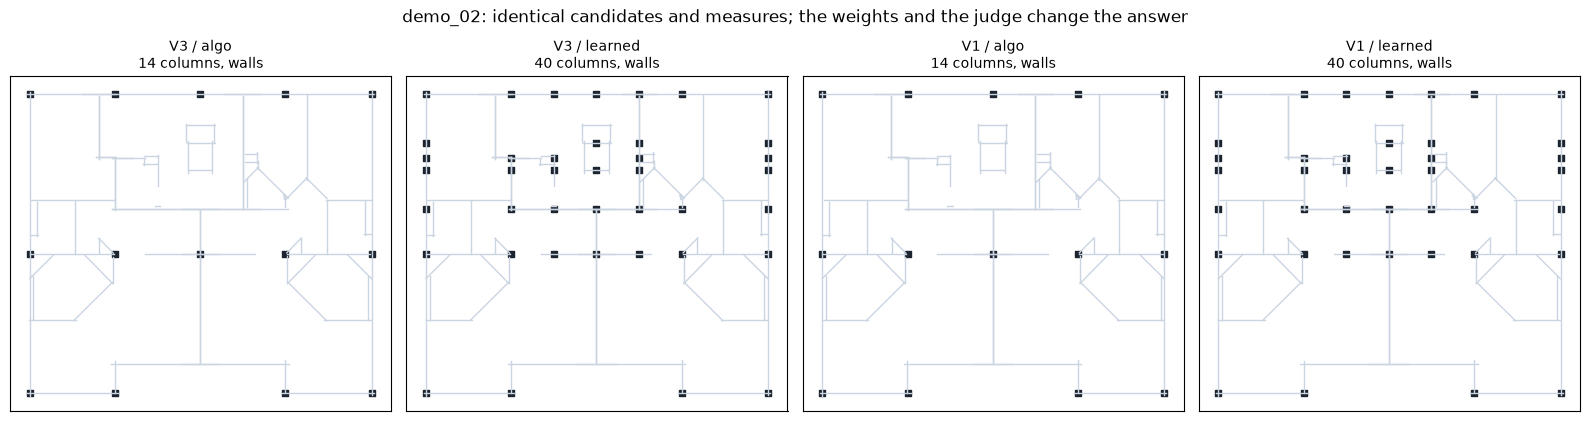

In [3]:
# The four answers, drawn.
fig, axes = plt.subplots(1, 4, figsize=(16, 4.2))
for ax, ((variant, mode), r) in zip(axes, runs.items()):
    for w in r["grid"]["walls"]:
        ax.plot([w[0], w[2]], [w[1], w[3]], color="#cbd5e1", lw=1.0)
    c = np.asarray(r["best"]["columns"])
    ax.scatter(c[:, 0], c[:, 1], s=20, c="#1c2430", marker="s")
    ax.set_title(f"{variant} / {mode}\n{len(c)} columns, "
                 f"{r['best']['placement']}", fontsize=10)
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("demo_02: identical candidates and measures; the weights and "
             "the judge change the answer", y=1.02)
fig.tight_layout()
fig.savefig(Path("..") / "figures" / "09_pipeline_output.png", dpi=150,
            bbox_inches="tight")
plt.show()

## Where the comparison is actually made

This notebook demonstrates that the machinery runs; it establishes nothing
about which variant is better. That question belongs to stage 12, which
runs all four variants under both sets of score weights on all seven
held-out plans, reports candidate coverage before any accuracy figure, and
compares variants with paired tests. The table below is read from its
output.

In [4]:
acc = pd.read_csv(Path("..") / "data" / "evaluation_accuracy.csv")
print("stage 12 accuracy table (mean over the seven held-out plans):")
print(acc.groupby(["mode", "variant"])[
    ["rank_gt", "top1", "top5", "chamfer_m", "iou"]]
    .mean().round(3).to_string())

stage 12 accuracy table (mean over the seven held-out plans):
                  rank_gt   top1   top5  chamfer_m    iou
mode    variant                                          
algo    V1       2429.286  0.000  0.000      1.000  0.287
        V2       2429.286  0.000  0.000      0.958  0.312
        V3       2429.286  0.000  0.000      1.000  0.287
        V4       2429.286  0.000  0.000      1.000  0.287
learned V1         21.857  0.000  0.429      0.248  0.704
        V2         21.714  0.143  0.429      0.264  0.718
        V3         21.714  0.143  0.429      0.271  0.722
        V4         22.000  0.143  0.429      0.282  0.683
